In [178]:
import pandas as pd
df=pd.read_csv('customer_churn.csv')
df

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,NaN,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1
...,...,...,...,...,...,...,...,...,...,...,...
995,60,56292.986659,751.728246,26,149.322171,120,93,4,Male,West,0
996,64,36687.617333,556.297594,40,44.289513,172,3,4,Male,South,1
997,62,43438.125495,698.504304,33,132.459634,3,52,2,Male,East,0
998,35,60835.720367,607.589743,49,72.489390,341,74,3,Male,West,1


In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    1000 non-null   int64  
 1   income                 951 non-null    float64
 2   credit_score           950 non-null    float64
 3   transactions_month     1000 non-null   int64  
 4   avg_purchase_value     950 non-null    float64
 5   days_since_last_login  1000 non-null   int64  
 6   tenure_months          1000 non-null   int64  
 7   num_products           1000 non-null   int64  
 8   gender                 1000 non-null   object 
 9   region                 1000 non-null   object 
 10  churn                  1000 non-null   int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 86.1+ KB


In [180]:
df['churn'].value_counts()

churn
1    517
0    483
Name: count, dtype: int64

In [181]:
df['gender'].value_counts()

gender
Female    513
Male      487
Name: count, dtype: int64

In [182]:
df.describe()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,churn
count,1000.00000,951.000000,950.000000,1000.000000,950.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.81900,55354.417513,651.422837,29.842000,119.301574,182.155000,60.394000,3.129000,0.517000
std,14.99103,32708.500386,68.271995,5.453511,39.619144,104.205824,34.163166,1.410088,0.499961
min,18.00000,7271.860691,444.172796,15.000000,-7.068153,0.000000,1.000000,1.000000,0.000000
25%,31.00000,40959.853770,605.096009,26.000000,93.330104,88.000000,31.000000,2.000000,0.000000
50%,44.00000,51298.846812,650.746768,30.000000,119.585761,184.000000,61.000000,3.000000,1.000000
75%,56.00000,61285.465584,697.845647,33.000000,146.374081,273.250000,89.250000,4.000000,1.000000
max,69.00000,254852.478291,873.517530,49.000000,244.516408,364.000000,119.000000,5.000000,1.000000


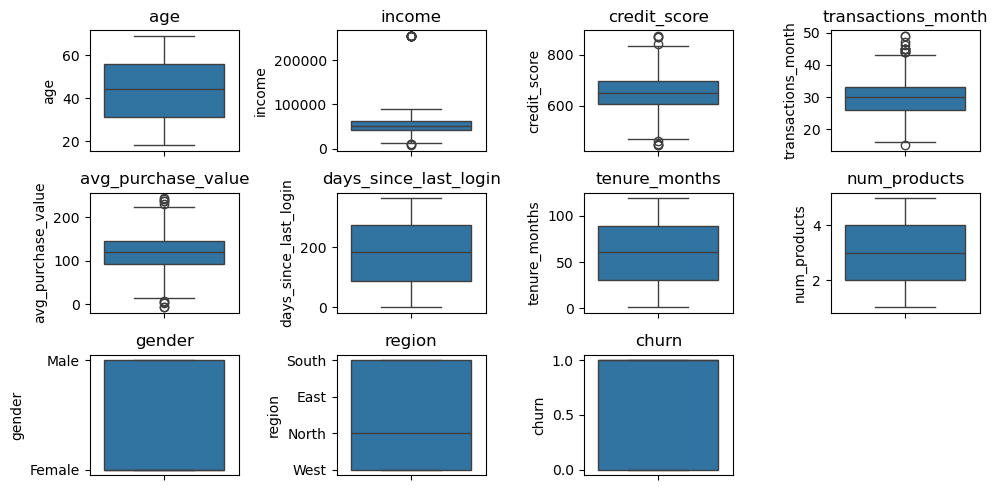

In [183]:
# show the outliers in each column
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
for i in df.columns:
    plt.subplot(3,4,df.columns.get_loc(i)+1)
    sns.boxplot(df[i])
    plt.title(i)
plt.tight_layout()
plt.show()



In [184]:
# mean mdian mode of income column
print(f'Mean: {df["income"].mean()}')
print(f'Median: {round(df["income"].median(), 7)}')
print(f'Mode: {df["income"].mode()[0]}')

Mean: 55354.41751318089
Median: 51298.8468121
Mode: 254852.4782908424


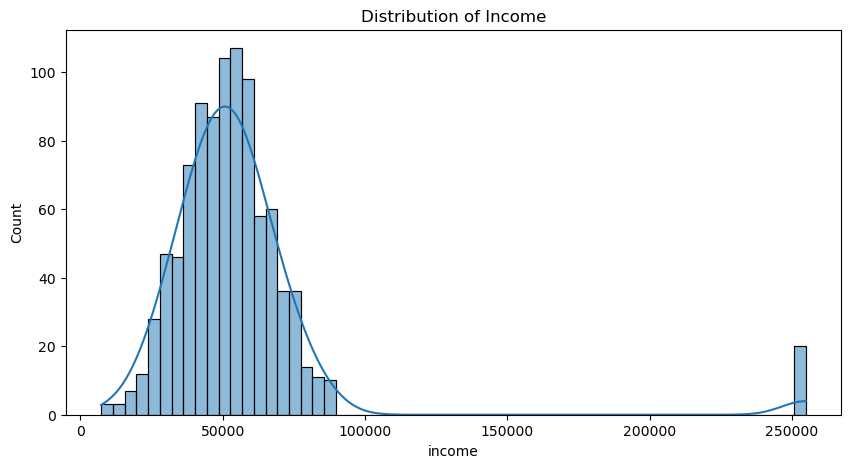

In [185]:
# distrubution of income column
plt.figure(figsize=(10,5))
sns.histplot(df['income'],kde=True)
plt.title('Distribution of Income')
plt.show()

In [186]:
# remove the outliers in income column
Q1=df['income'].quantile(0.25)
Q3=df['income'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df=df[(df['income']>=lower_bound) & (df['income']<=upper_bound)]


In [187]:
# fill the missing values in income column with median
df['income'].fillna(df['income'].median(), inplace=True)

C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_24124\2375908094.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['income'].fillna(df['income'].median(), inplace=True)
C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_24124\2375908094.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['income'].fillna(df['income'].median(), inplace

In [188]:
df['credit_score'].value_counts()

credit_score
622.025467    1
627.759943    1
754.290441    1
537.936722    1
592.005208    1
             ..
640.812012    1
655.379632    1
634.260081    1
604.499819    1
770.356453    1
Name: count, Length: 883, dtype: int64

In [189]:
# find the mean, median and mode of credit score column']
print(f'Mean: {round(df["credit_score"].mean(), 7)}')
print(f'Median: {df["credit_score"].median()}')
print(f'Mode: {df["credit_score"].mode()[0]}')

Mean: 651.5704743
Median: 650.4759891191999
Mode: 444.1727955735004


In [190]:
# fix the outliers in credit score column
Q1=df['credit_score'].quantile(0.25)
Q3=df['credit_score'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df['credit_score']=df['credit_score'].apply(lambda x: upper_bound if x>upper_bound else (lower_bound if x<lower_bound else x))  


C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_24124\1699514302.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['credit_score']=df['credit_score'].apply(lambda x: upper_bound if x>upper_bound else (lower_bound if x<lower_bound else x))


<Axes: ylabel='credit_score'>

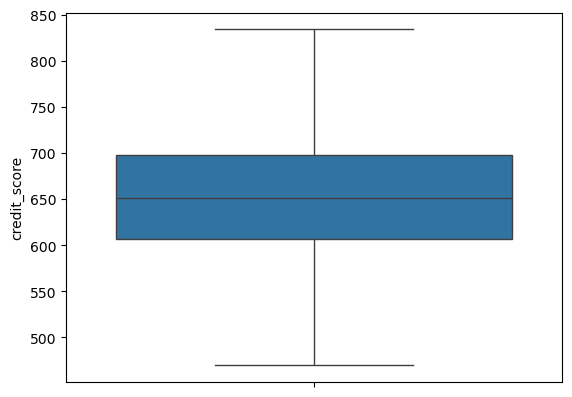

In [191]:
sns.boxplot(df['credit_score'])

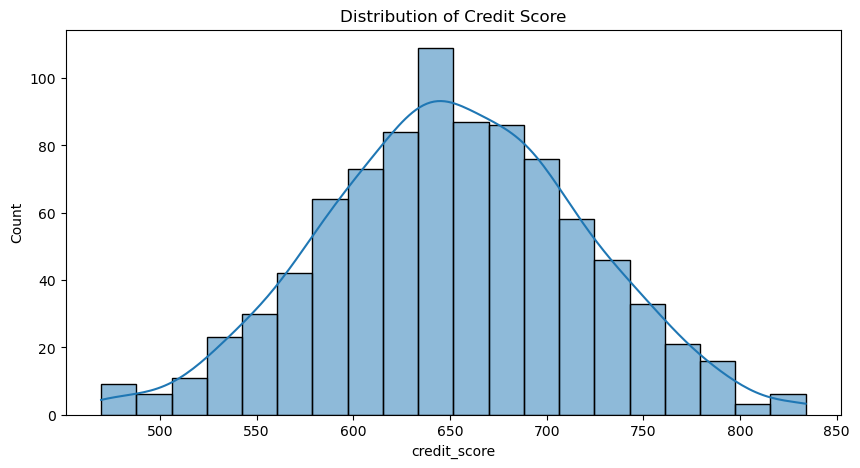

In [192]:
plt.figure(figsize=(10,5))
sns.histplot(df['credit_score'],kde=True)
plt.title('Distribution of Credit Score')
plt.show()

In [193]:
df['credit_score'].fillna(df['credit_score'].mean(), inplace=True)

C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_24124\952142757.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['credit_score'].fillna(df['credit_score'].mean(), inplace=True)
C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_24124\952142757.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['credit_score'].fillna(df['credit_score

In [194]:
df.isnull().sum()

age                       0
income                    0
credit_score              0
transactions_month        0
avg_purchase_value       47
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

In [195]:
df['avg_purchase_value'].value_counts()

avg_purchase_value
133.943805    1
133.377541    1
111.804933    1
121.255835    1
184.303132    1
             ..
136.590916    1
184.173564    1
125.545807    1
76.554948     1
104.107070    1
Name: count, Length: 881, dtype: int64

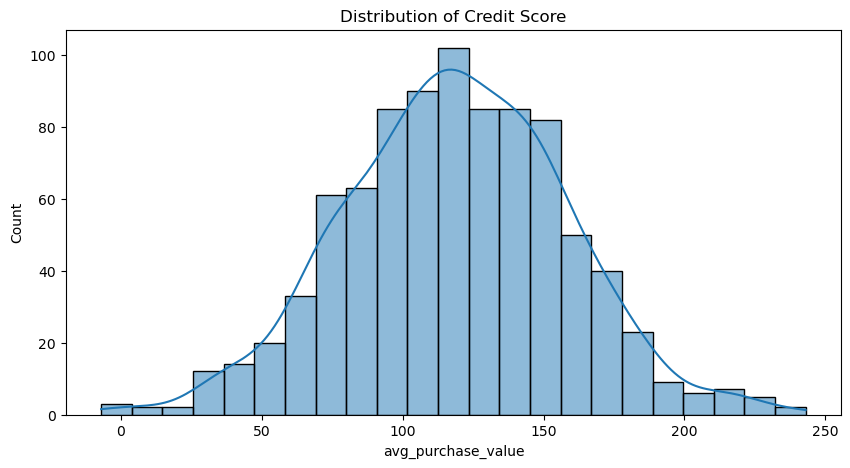

In [196]:
plt.figure(figsize=(10,5))
sns.histplot(df['avg_purchase_value'],kde=True)
plt.title('Distribution of Credit Score')
plt.show()

In [197]:
df

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,651.517790,27,115.391031,168,99,2,Male,East,1
6,38,75307.124526,651.517790,40,141.636341,84,96,1,Female,North,0
...,...,...,...,...,...,...,...,...,...,...,...
995,60,56292.986659,751.728246,26,149.322171,120,93,4,Male,West,0
996,64,36687.617333,556.297594,40,44.289513,172,3,4,Male,South,1
997,62,43438.125495,698.504304,33,132.459634,3,52,2,Male,East,0
998,35,60835.720367,607.589743,49,72.489390,341,74,3,Male,West,1


In [198]:
# mean, median and mode of avg_purchase_value column
print(f'Mean: {round(df["avg_purchase_value"].mean(), 7)}')
print(f'Median: {round(df["avg_purchase_value"].median(), 7)}')
print(f'Mode: {df["avg_purchase_value"].mode()[0]}')

Mean: 118.6524981
Median: 118.642991
Mode: -7.068152527840027


In [199]:
# iqr method to fix the outliers in avg_purchase_value column
Q1=df['avg_purchase_value'].quantile(0.25)
Q3=df['avg_purchase_value'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df['avg_purchase_value']=df['avg_purchase_value'].apply(lambda x: upper_bound if x>upper_bound else (lower_bound if x<lower_bound else x))

C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_24124\915511897.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['avg_purchase_value']=df['avg_purchase_value'].apply(lambda x: upper_bound if x>upper_bound else (lower_bound if x<lower_bound else x))


In [200]:
df['avg_purchase_value']=df['avg_purchase_value'].fillna(df['avg_purchase_value'].median())

C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_24124\3201748290.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['avg_purchase_value']=df['avg_purchase_value'].fillna(df['avg_purchase_value'].median())


In [201]:
df.isnull().sum()

age                      0
income                   0
credit_score             0
transactions_month       0
avg_purchase_value       0
days_since_last_login    0
tenure_months            0
num_products             0
gender                   0
region                   0
churn                    0
dtype: int64

In [202]:
# transactions_month handle the outliers
Q1=df['transactions_month'].quantile(0.25)
Q3=df['transactions_month'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df['transactions_month']=df['transactions_month'].apply(lambda x: upper_bound if x>upper_bound else (lower_bound if x<lower_bound else x))

C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_24124\2100751285.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['transactions_month']=df['transactions_month'].apply(lambda x: upper_bound if x>upper_bound else (lower_bound if x<lower_bound else x))


<Axes: ylabel='transactions_month'>

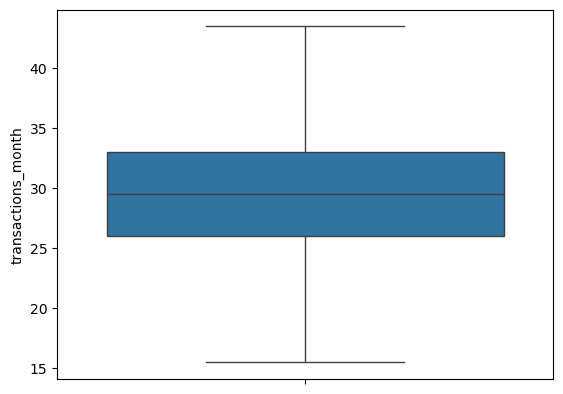

In [203]:
sns.boxplot(df['transactions_month'])

In [204]:
# find the categorical columns in the dataset
categorical_cols=df.select_dtypes(include='object').columns
categorical_cols

Index(['gender', 'region'], dtype='object')

In [205]:
df['gender']=df['gender'].replace({'Male':0,'Female':1} )

C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_24124\1307541401.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender']=df['gender'].replace({'Male':0,'Female':1} )
C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_24124\1307541401.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gender']=df['gender'].replace({'Male':0,'Female':1} )


In [206]:
# convert the region column into numerical values using one hot encoding
df=pd.get_dummies(df,columns=['region'])

In [207]:
df

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,churn,region_East,region_North,region_South,region_West
1,69,53051.954538,622.025467,41.0,133.943805,72,96,4,1,1,True,False,False,False
2,46,38654.738821,665.727931,36.0,114.993023,155,88,3,0,1,False,True,False,False
3,32,28666.194356,715.281358,29.0,153.875284,76,110,2,0,0,False,False,True,False
4,60,40301.406736,651.517790,27.0,115.391031,168,99,2,0,1,True,False,False,False
6,38,75307.124526,651.517790,40.0,141.636341,84,96,1,1,0,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,60,56292.986659,751.728246,26.0,149.322171,120,93,4,0,0,False,False,False,True
996,64,36687.617333,556.297594,40.0,44.289513,172,3,4,0,1,False,False,True,False
997,62,43438.125495,698.504304,33.0,132.459634,3,52,2,0,0,True,False,False,False
998,35,60835.720367,607.589743,43.5,72.489390,341,74,3,0,1,False,False,False,True


In [208]:
# change boolean values into 0 and 1
bool_cols=df.select_dtypes(include='bool').columns
for col in bool_cols:
    df[col]=df[col].astype(int)

In [209]:
df

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,churn,region_East,region_North,region_South,region_West
1,69,53051.954538,622.025467,41.0,133.943805,72,96,4,1,1,1,0,0,0
2,46,38654.738821,665.727931,36.0,114.993023,155,88,3,0,1,0,1,0,0
3,32,28666.194356,715.281358,29.0,153.875284,76,110,2,0,0,0,0,1,0
4,60,40301.406736,651.517790,27.0,115.391031,168,99,2,0,1,1,0,0,0
6,38,75307.124526,651.517790,40.0,141.636341,84,96,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,60,56292.986659,751.728246,26.0,149.322171,120,93,4,0,0,0,0,0,1
996,64,36687.617333,556.297594,40.0,44.289513,172,3,4,0,1,0,0,1,0
997,62,43438.125495,698.504304,33.0,132.459634,3,52,2,0,0,1,0,0,0
998,35,60835.720367,607.589743,43.5,72.489390,341,74,3,0,1,0,0,0,1


In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 928 entries, 1 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    928 non-null    int64  
 1   income                 928 non-null    float64
 2   credit_score           928 non-null    float64
 3   transactions_month     928 non-null    float64
 4   avg_purchase_value     928 non-null    float64
 5   days_since_last_login  928 non-null    int64  
 6   tenure_months          928 non-null    int64  
 7   num_products           928 non-null    int64  
 8   gender                 928 non-null    int64  
 9   churn                  928 non-null    int64  
 10  region_East            928 non-null    int64  
 11  region_North           928 non-null    int64  
 12  region_South           928 non-null    int64  
 13  region_West            928 non-null    int64  
dtypes: float64(4), int64(10)
memory usage: 108.8 KB


<Axes: xlabel='avg_purchase_value', ylabel='Count'>

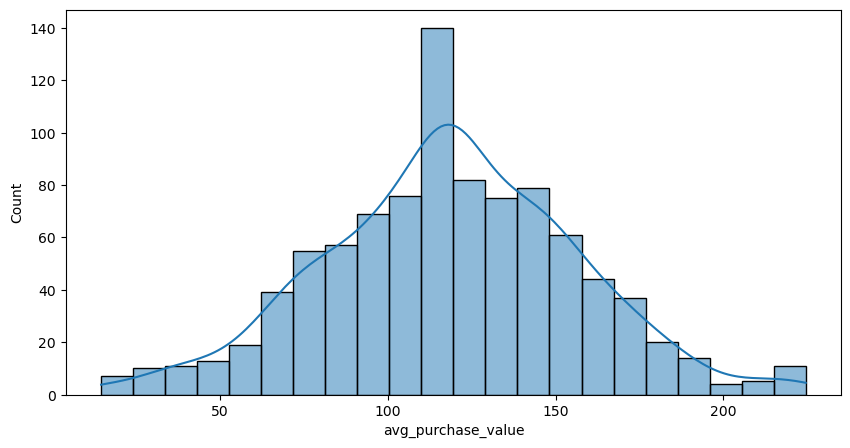

In [213]:
plt.figure(figsize=(10,5))
sns.histplot(df['avg_purchase_value'],kde=True)

In [214]:
# give scaling to the income, credit_score, avg_purchase_value and transactions_month columns
# import the minmaxscaler
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
cols_to_scale=['income','credit_score','avg_purchase_value','transactions_month']
df[cols_to_scale]=scaler.fit_transform(df[cols_to_scale])
df

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,churn,region_East,region_North,region_South,region_West
1,69,0.526692,0.418479,0.910714,0.568649,72,96,4,1,1,1,0,0,0
2,46,0.339658,0.538418,0.732143,0.478432,155,88,3,0,1,0,1,0,0
3,32,0.209898,0.674416,0.482143,0.663535,76,110,2,0,0,0,0,1,0
4,60,0.361050,0.499419,0.410714,0.480327,168,99,2,0,1,1,0,0,0
6,38,0.815807,0.499419,0.875000,0.605270,84,96,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,60,0.568796,0.774442,0.375000,0.641859,120,93,4,0,0,0,0,0,1
996,64,0.314104,0.238092,0.875000,0.141842,172,3,4,0,1,0,0,1,0
997,62,0.401799,0.628372,0.625000,0.561584,3,52,2,0,0,1,0,0,0
998,35,0.627810,0.378861,1.000000,0.276090,341,74,3,0,1,0,0,0,1


In [227]:
from sklearn.model_selection import train_test_split

X=df.drop('churn',axis=1)
y=df['churn']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [228]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)


c:\Users\Sree Charan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [229]:
y_pred=model.predict(X_test)

In [231]:
y_pred

array([0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 1])

In [236]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,r2_score

print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print("Accuracy:", accuracy_score(y_test,y_pred))      

              precision    recall  f1-score   support

           0       0.46      0.46      0.46        84
           1       0.55      0.55      0.55       102

    accuracy                           0.51       186
   macro avg       0.51      0.51      0.51       186
weighted avg       0.51      0.51      0.51       186

[[39 45]
 [46 56]]
Accuracy: 0.510752688172043


In [233]:
# difference between actual and predicted values
diff=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
diff

,Actual,Predicted
816,0,0
721,0,0
33,0,0
421,1,1
210,1,1
...,...,...
440,1,0
7,1,0
58,0,1
395,1,1


In [234]:
# training accuracy
train_acc=model.score(X_train,y_train)

In [235]:
train_acc

0.5309973045822103